In [171]:
import networkx as nx
from matplotlib import pyplot as plt

In [172]:
G = nx.DiGraph()

In [173]:
print(G)

DiGraph with 0 nodes and 0 edges


In [174]:
def find_break_point_for_knot(G, cycle):
    loop = cycle + [cycle[0]]

    edges = []

    for i in range(len(loop) - 1):
        u, v = loop[i], loop[i + 1]

        if not G.has_edge(u, v):
            continue

        w = G[u][v]['weight']

        # ----------------------------
        # Role importance heuristic
        # ----------------------------
        role_score = 1

        if u in ["Fear", "Anxiety", "Shame", "Helplessness"]:
            role_score += 1

        if v in ["Avoidance", "Fear", "IntrusionFlashback"]:
            role_score += 1

        break_score = abs(w) * role_score

        edges.append((u, v, w, break_score))

    # weakest effective edge
    weakest = min(edges, key=lambda x: x[3])

    return weakest, edges

In [175]:
def plot_break_point(cycle, weakest_edge, all_edges):
    labels = [f"{u}->{v}" for u, v, _, _ in all_edges]
    values = [b for _, _, _, b in all_edges]

    plt.figure(figsize=(7,4))

    plt.bar(labels, values)

    # highlight weakest edge
    w_u, w_v, _, _ = weakest_edge
    plt.title(f"Break Point: {w_u} → {w_v}")

    plt.ylabel("Break Score")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [176]:
def detect_trauma_knots(G, top_k=5):
    import networkx as nx

    cycles = list(nx.simple_cycles(G))
    knots = []

    for cycle in cycles:
        if len(cycle) < 2:
            continue

        loop = cycle + [cycle[0]]

        total_weight = 0
        edge_list = []

        for i in range(len(loop) - 1):
            u, v = loop[i], loop[i + 1]

            if G.has_edge(u, v):
                w = G[u][v]['weight']
                total_weight += abs(w)
                edge_list.append((u, v, w))

        score = total_weight

        # IMPORTANT: return 3 values now
        knots.append((cycle, score, edge_list))

    knots.sort(key=lambda x: -x[1])

    return knots[:top_k]

In [177]:
def plot_node_activation(activation, top_n=10):
    sorted_nodes = sorted(activation.items(), key=lambda x: -abs(x[1]))[:top_n]

    nodes = [n for n, _ in sorted_nodes]
    values = [v for _, v in sorted_nodes]

    plt.figure(figsize=(10,5))
    plt.bar(nodes, values)

    plt.title("Top Activated Emotional Nodes")
    plt.ylabel("Activation Strength")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [178]:
def plot_edge_influence(path_tracker, top_n=10):
    sorted_edges = sorted(path_tracker.items(), key=lambda x: -abs(x[1]))[:top_n]

    labels = [f"{u}->{v}" for (u, v), _ in sorted_edges]
    values = [val for _, val in sorted_edges]

    plt.figure(figsize=(10,5))
    plt.bar(labels, values)

    plt.title("Top Trauma Activation Paths")
    plt.ylabel("Influence Strength")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [179]:
def simulate_activation(G, start_node, steps=5, decay=0.5, threshold=0.01):
    """
    Simulates activation spreading through graph with path tracking.
    """

    # ----------------------------
    # INITIALIZATION
    # ----------------------------
    activation = {node: 0 for node in G.nodes()}
    activation[start_node] = 1.0

    path_tracker = {}  # ✅ FIX: global tracker (not inside loop)

    print(f"\n--- Activation Start: {start_node} ---")

    # ----------------------------
    # PROPAGATION LOOP
    # ----------------------------
    for step in range(steps):
        new_activation = activation.copy()

        print(f"\nStep {step+1}")

        for u in G.nodes():
            if activation[u] == 0:
                continue

            for v in G.successors(u):

                weight = G[u][v]['weight']

                # normalize + decay
                influence = activation[u] * (weight / 10.0) * decay

                if abs(influence) < threshold:
                    continue

                # ----------------------------
                # PATH TRACKING (FIXED)
                # ----------------------------
                if (u, v) not in path_tracker:
                    path_tracker[(u, v)] = 0

                path_tracker[(u, v)] += influence

                new_activation[v] += influence

                print(f"{u} → {v} | influence: {influence:.3f}")

        activation = new_activation

        # ----------------------------
        # TOP ACTIVE NODES
        # ----------------------------
        sorted_nodes = sorted(activation.items(), key=lambda x: -abs(x[1]))

        print("\nTop activations:")
        for node, val in sorted_nodes[:5]:
            print(f"{node}: {val:.3f}")

    # ----------------------------
    # FINAL ANALYSIS
    # ----------------------------
    print("\n--- Most Influential Paths ---")
    sorted_edges = sorted(path_tracker.items(), key=lambda x: -abs(x[1]))

    for (u, v), val in sorted_edges[:10]:
        print(f"{u} → {v}: {val:.3f}")

    return activation, path_tracker

In [180]:
fear_nodes = [
    "PhysicalThreat",
    "DiseaseTrauma",
    "AccidentTrauma",
    "ViolenceExposure",
    "LossOfSafety",
    "AbandonmentFear",
    "WarTrauma"
]
shame_nodes = [
    "Rejection",
    "SocialHumiliation",
    "PublicFailure",
    "Bullying",
    "Comparison",
    "BodyShame"
]
guilt_nodes = [
    "MoralFailure",
    "SurvivorGuilt",
    "HarmToOthers",
    "NeglectResponsibility"
]
loss_nodes = [
    "LossOfLovedOnes",
    "Breakup",
    "Divorce",
    "Separation",
    "EmotionalNeglect"
]
control_nodes = [
    "JobLoss",
    "WealthLoss",
    "FailureRepeated",
    "ChronicStress",
    "Uncertainty"
]
internal_nodes = [
    "Fear", "Shame", "Anxiety", "Anger",
    "Guilt", "Helplessness",
    "Hypervigilance", "StartleResponse",
    "IntrusionFlashback", "Dissociation", "Numbness"
]
cognitive_nodes = [
    "NegativeBelief",
    "SelfDoubt",
    "CatastrophicThinking"
]
behavior_nodes = [
    "Avoidance",
    "Withdrawal",
    "Overthinking",
    "CompulsiveBehavior"
]
healing_nodes = [
    "Support", "Safety", "Confidence", "Empowerment",
    "Awareness", "EmotionalProcessing", "Exposure",
    "Resilience", "Acceptance"
]
G.add_nodes_from(healing_nodes)
G.add_nodes_from(behavior_nodes)
G.add_nodes_from(cognitive_nodes)
G.add_nodes_from(internal_nodes)
G.add_nodes_from(control_nodes)
G.add_nodes_from(loss_nodes)
G.add_nodes_from(guilt_nodes)
G.add_nodes_from(fear_nodes)
G.add_nodes_from(shame_nodes)

In [181]:
print(G)
print(G.nodes)

DiGraph with 54 nodes and 0 edges
['Support', 'Safety', 'Confidence', 'Empowerment', 'Awareness', 'EmotionalProcessing', 'Exposure', 'Resilience', 'Acceptance', 'Avoidance', 'Withdrawal', 'Overthinking', 'CompulsiveBehavior', 'NegativeBelief', 'SelfDoubt', 'CatastrophicThinking', 'Fear', 'Shame', 'Anxiety', 'Anger', 'Guilt', 'Helplessness', 'Hypervigilance', 'StartleResponse', 'IntrusionFlashback', 'Dissociation', 'Numbness', 'JobLoss', 'WealthLoss', 'FailureRepeated', 'ChronicStress', 'Uncertainty', 'LossOfLovedOnes', 'Breakup', 'Divorce', 'Separation', 'EmotionalNeglect', 'MoralFailure', 'SurvivorGuilt', 'HarmToOthers', 'NeglectResponsibility', 'PhysicalThreat', 'DiseaseTrauma', 'AccidentTrauma', 'ViolenceExposure', 'LossOfSafety', 'AbandonmentFear', 'WarTrauma', 'Rejection', 'SocialHumiliation', 'PublicFailure', 'Bullying', 'Comparison', 'BodyShame']


In [182]:
edges = []

# ----------------------------
# 1) Build node_types from your lists
# ----------------------------
node_types = {}

for n in fear_nodes:
    node_types[n] = node_types.get(n, []) + ["fear"]

for n in shame_nodes:
    node_types[n] = node_types.get(n, []) + ["shame"]

for n in guilt_nodes:
    node_types[n] = node_types.get(n, []) + ["guilt"]

for n in loss_nodes:
    node_types[n] = node_types.get(n, []) + ["loss"]

for n in control_nodes:
    node_types[n] = node_types.get(n, []) + ["control"]

# (Optional) allow multi-type nodes if you want later:
# node_types["Breakup"] = ["loss", "shame"]


# ----------------------------
# 2) Trauma → Emotion rules
# ----------------------------
trauma_to_emotion = {
    "fear": [("Fear", 9), ("Anxiety", 8)],
    "shame": [("Shame", 9), ("Fear", 8)],
    "guilt": [("Guilt", 9), ("NegativeBelief", 8)],
    "loss": [("Fear", 9), ("Helplessness", 9)],
    "control": [("Anxiety", 9), ("Helplessness", 8)]
}

for node, types in node_types.items():
    for t in types:
        for target, w in trauma_to_emotion.get(t, []):
            edges.append((node, target, w))


# ----------------------------
# 3) Emotion → Cognition
# ----------------------------
edges += [
    ("Fear", "NegativeBelief", 9),
    ("Shame", "NegativeBelief", 8),
    ("Guilt", "NegativeBelief", 7),
    ("Helplessness", "NegativeBelief", 9),

    ("Anxiety", "CatastrophicThinking", 8),
    ("CatastrophicThinking", "NegativeBelief", 8),
    ("SelfDoubt", "NegativeBelief", 7)
]


# ----------------------------
# 4) Cognition → Behavior (core knot)
# ----------------------------
edges += [
    ("NegativeBelief", "Avoidance", 9),
    ("NegativeBelief", "Withdrawal", 8),

    ("Avoidance", "Fear", 9),
    ("Avoidance", "Anxiety", 8),

    ("Withdrawal", "Shame", 7),
    ("Overthinking", "Anxiety", 8),
    ("CompulsiveBehavior", "Anxiety", 7)
]


# ----------------------------
# 5) Amplifier loops
# ----------------------------
edges += [
    ("Fear", "Hypervigilance", 9),
    ("Hypervigilance", "StartleResponse", 8),
    ("StartleResponse", "Fear", 9),

    ("Fear", "IntrusionFlashback", 9),
    ("IntrusionFlashback", "Fear", 10)
]


# ----------------------------
# 6) Shutdown / dissociation path
# ----------------------------
edges += [
    ("Fear", "Dissociation", 7),
    ("Dissociation", "Numbness", 8),
    ("Numbness", "Avoidance", 7)
]


# ----------------------------
# 7) Helplessness + anger paths
# ----------------------------
edges += [
    ("Fear", "Helplessness", 8),
    ("Helplessness", "Avoidance", 9),

    ("Fear", "Anger", 7),
    ("Anger", "NegativeBelief", 7)
]


# ----------------------------
# 8) Healing / recovery rules
# ----------------------------
edges += [
    ("Support", "Safety", 8),
    ("Safety", "Fear", -8),

    ("Support", "Confidence", 7),
    ("Confidence", "Empowerment", 8),
    ("Empowerment", "NegativeBelief", -7),

    ("Awareness", "NegativeBelief", -6),
    ("EmotionalProcessing", "Fear", -7),
    ("Exposure", "Avoidance", -8),

    ("Confidence", "Avoidance", -6),
    ("Resilience", "Fear", -6),
    ("Acceptance", "Shame", -6)
]


# ----------------------------
# 9) Finally add to graph
# ----------------------------
G.add_weighted_edges_from(edges)

In [183]:
print(G.edges.data())

[('Support', 'Safety', {'weight': 8}), ('Support', 'Confidence', {'weight': 7}), ('Safety', 'Fear', {'weight': -8}), ('Confidence', 'Empowerment', {'weight': 8}), ('Confidence', 'Avoidance', {'weight': -6}), ('Empowerment', 'NegativeBelief', {'weight': -7}), ('Awareness', 'NegativeBelief', {'weight': -6}), ('EmotionalProcessing', 'Fear', {'weight': -7}), ('Exposure', 'Avoidance', {'weight': -8}), ('Resilience', 'Fear', {'weight': -6}), ('Acceptance', 'Shame', {'weight': -6}), ('Avoidance', 'Fear', {'weight': 9}), ('Avoidance', 'Anxiety', {'weight': 8}), ('Withdrawal', 'Shame', {'weight': 7}), ('Overthinking', 'Anxiety', {'weight': 8}), ('CompulsiveBehavior', 'Anxiety', {'weight': 7}), ('NegativeBelief', 'Avoidance', {'weight': 9}), ('NegativeBelief', 'Withdrawal', {'weight': 8}), ('SelfDoubt', 'NegativeBelief', {'weight': 7}), ('CatastrophicThinking', 'NegativeBelief', {'weight': 8}), ('Fear', 'NegativeBelief', {'weight': 9}), ('Fear', 'Hypervigilance', {'weight': 9}), ('Fear', 'Intrus

In [184]:
# ----------------------------
# 2. Find Cycles
# ----------------------------
def get_cycles(G):
    return list(nx.simple_cycles(G))

In [185]:
# ----------------------------
# 3. Trauma Detection (SMART)
# ----------------------------
def detect_trauma_cycles(G, cycles, weight_threshold=4):
    trauma_cycles = []

    for cycle in cycles:
        weights = []
        for i in range(len(cycle)):
            u = cycle[i]
            v = cycle[(i+1) % len(cycle)]
            weights.append(G[u][v]['weight'])

        avg_weight = sum(weights) / len(weights)

        if avg_weight >= weight_threshold:
            trauma_cycles.append(cycle)
    print(trauma_cycles)
    return trauma_cycles

In [186]:
# ----------------------------
# 4. Complexity Function
# ----------------------------
def compute_K(G, cycles, alpha=1, beta=1):
    total = 0

    for cycle in cycles:
        strength = 0
        for i in range(len(cycle)):
            u = cycle[i]
            v = cycle[(i+1) % len(cycle)]
            strength += G[u][v]['weight']

        total += alpha * strength + beta * len(cycle)

    print(total)
    return total

In [187]:
# ----------------------------
# 5. Reinforcement (Trauma Growth)
# ----------------------------
def reinforce(G, cycles, factor=1.1):
    for cycle in cycles:
        for i in range(len(cycle)):
            u = cycle[i]
            v = cycle[(i+1) % len(cycle)]
            G[u][v]['weight'] *= factor

In [188]:
# ----------------------------
# 6. Targeted Weakening (SMART)
# ----------------------------
def weaken_targeted(G, trauma_cycles, factor=0.7):
    for cycle in trauma_cycles:
        for i in range(len(cycle)):
            u = cycle[i]
            v = cycle[(i+1) % len(cycle)]
            G[u][v]['weight'] *= factor

In [189]:
# ----------------------------
# 7. Visualization
# ----------------------------
def draw_graph(G, title):
    pos = nx.spring_layout(G)
    weights = nx.get_edge_attributes(G, 'weight')

    nx.draw(G, pos, with_labels=True)
    nx.draw_networkx_edge_labels(G, pos, edge_labels={
        k: round(v,2) for k,v in weights.items()
    })

    plt.title(title)
    plt.show()


--- INITIAL STATE ---
[['Anger', 'NegativeBelief', 'Avoidance', 'Fear'], ['Anxiety', 'CatastrophicThinking', 'NegativeBelief', 'Avoidance'], ['Avoidance', 'Fear', 'NegativeBelief'], ['Avoidance', 'Fear', 'Dissociation', 'Numbness'], ['Avoidance', 'Fear', 'Helplessness', 'NegativeBelief'], ['Avoidance', 'Fear', 'Helplessness'], ['Fear', 'Hypervigilance', 'StartleResponse'], ['Fear', 'IntrusionFlashback'], ['NegativeBelief', 'Withdrawal', 'Shame']]
282
Trauma Cycles: [['Anger', 'NegativeBelief', 'Avoidance', 'Fear'], ['Anxiety', 'CatastrophicThinking', 'NegativeBelief', 'Avoidance'], ['Avoidance', 'Fear', 'NegativeBelief'], ['Avoidance', 'Fear', 'Dissociation', 'Numbness'], ['Avoidance', 'Fear', 'Helplessness', 'NegativeBelief'], ['Avoidance', 'Fear', 'Helplessness'], ['Fear', 'Hypervigilance', 'StartleResponse'], ['Fear', 'IntrusionFlashback'], ['NegativeBelief', 'Withdrawal', 'Shame']]
K(G) before: 282


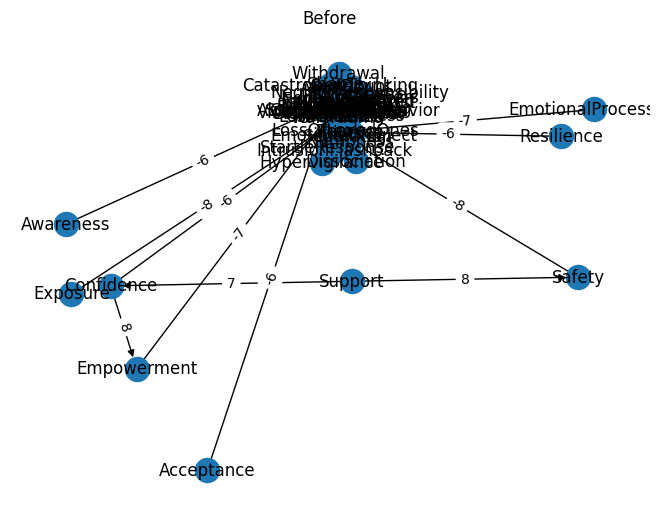


--- Activation Start: Fear ---

Step 1
Fear → NegativeBelief | influence: 0.450
Fear → Hypervigilance | influence: 0.450
Fear → IntrusionFlashback | influence: 0.450
Fear → Dissociation | influence: 0.350
Fear → Helplessness | influence: 0.400
Fear → Anger | influence: 0.350

Top activations:
Fear: 1.000
NegativeBelief: 0.450
Hypervigilance: 0.450
IntrusionFlashback: 0.450
Helplessness: 0.400

Step 2
NegativeBelief → Avoidance | influence: 0.203
NegativeBelief → Withdrawal | influence: 0.180
Fear → NegativeBelief | influence: 0.450
Fear → Hypervigilance | influence: 0.450
Fear → IntrusionFlashback | influence: 0.450
Fear → Dissociation | influence: 0.350
Fear → Helplessness | influence: 0.400
Fear → Anger | influence: 0.350
Anger → NegativeBelief | influence: 0.122
Helplessness → NegativeBelief | influence: 0.180
Helplessness → Avoidance | influence: 0.180
Hypervigilance → StartleResponse | influence: 0.180
IntrusionFlashback → Fear | influence: 0.225
Dissociation → Numbness | influen

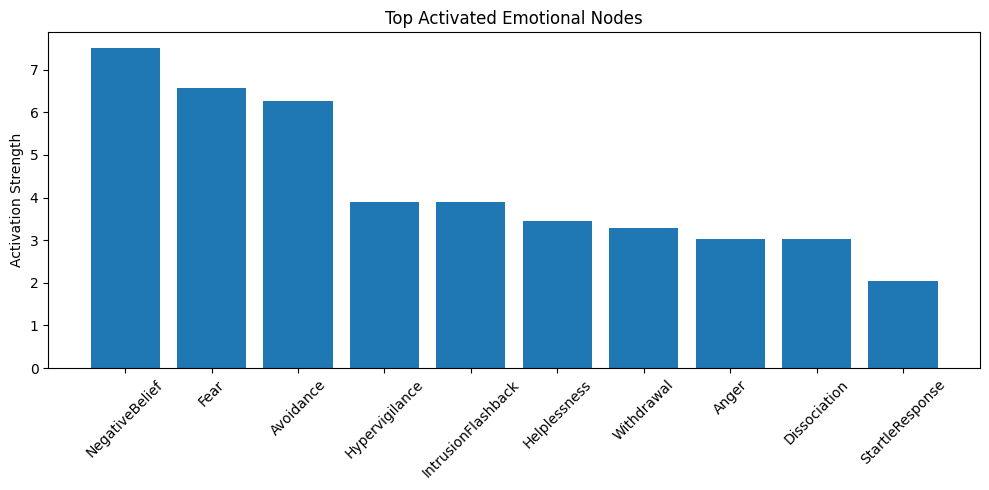

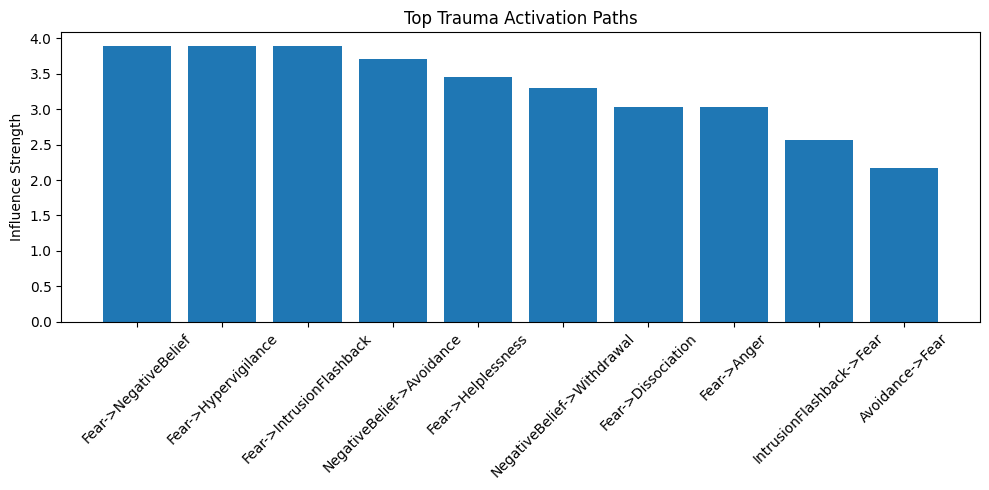


🔥 Trauma Knot 1:
Avoidance → Fear → Helplessness → NegativeBelief

💡 Weakest Break Edge:
Fear → Helplessness | weight=8 | break_score=16


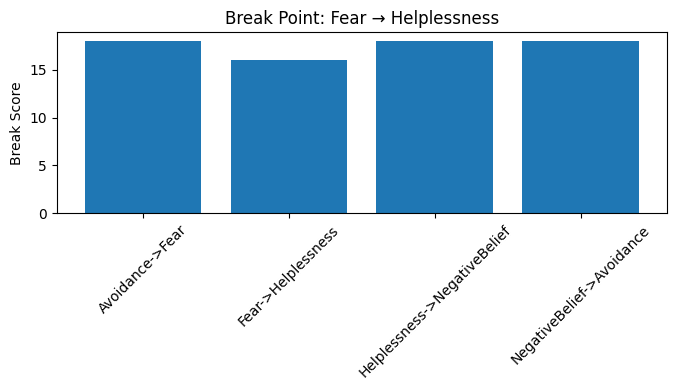


🔥 Trauma Knot 2:
Anxiety → CatastrophicThinking → NegativeBelief → Avoidance

💡 Weakest Break Edge:
CatastrophicThinking → NegativeBelief | weight=8 | break_score=8


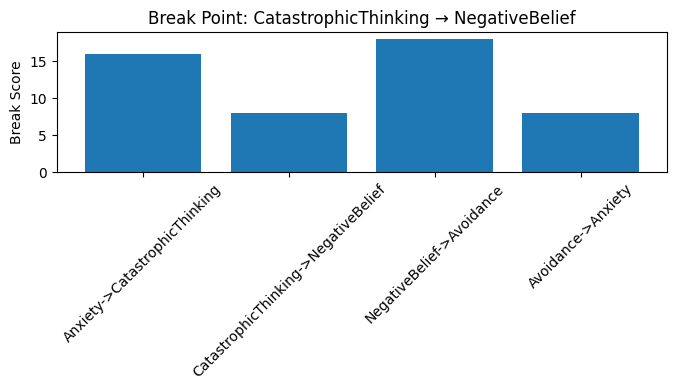


🔥 Trauma Knot 3:
Anger → NegativeBelief → Avoidance → Fear

💡 Weakest Break Edge:
Anger → NegativeBelief | weight=7 | break_score=7


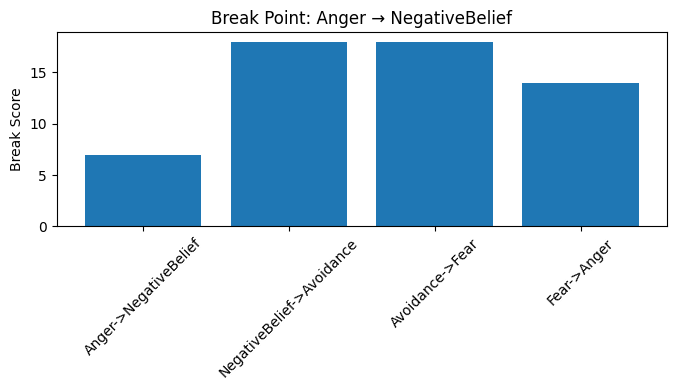


--- AFTER REINFORCEMENT ---
[['Anger', 'NegativeBelief', 'Avoidance', 'Fear'], ['Anxiety', 'CatastrophicThinking', 'NegativeBelief', 'Avoidance'], ['Avoidance', 'Fear', 'NegativeBelief'], ['Avoidance', 'Fear', 'Dissociation', 'Numbness'], ['Avoidance', 'Fear', 'Helplessness', 'NegativeBelief'], ['Avoidance', 'Fear', 'Helplessness'], ['Fear', 'Hypervigilance', 'StartleResponse'], ['Fear', 'IntrusionFlashback'], ['NegativeBelief', 'Withdrawal', 'Shame']]
425.664
K(G) after reinforcement: 425.664


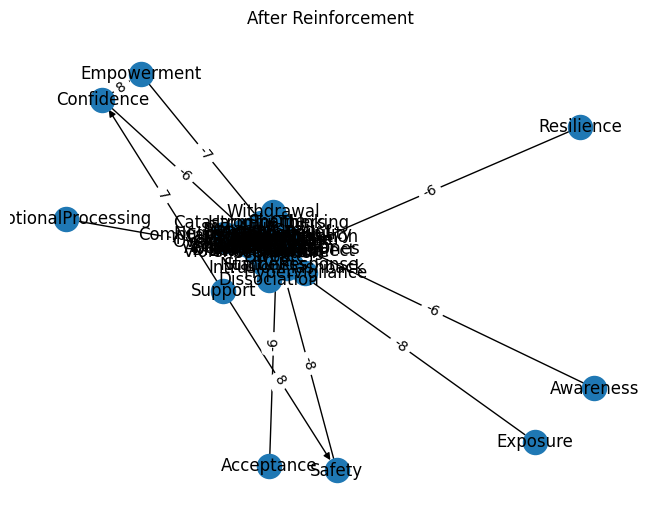


--- Activation Start: Fear ---

Step 1
Fear → NegativeBelief | influence: 0.540
Fear → Hypervigilance | influence: 0.540
Fear → IntrusionFlashback | influence: 0.540
Fear → Dissociation | influence: 0.420
Fear → Helplessness | influence: 0.576
Fear → Anger | influence: 0.420

Top activations:
Fear: 1.000
Helplessness: 0.576
NegativeBelief: 0.540
Hypervigilance: 0.540
IntrusionFlashback: 0.540

Step 2
NegativeBelief → Avoidance | influence: 0.504
NegativeBelief → Withdrawal | influence: 0.259
Fear → NegativeBelief | influence: 0.540
Fear → Hypervigilance | influence: 0.540
Fear → IntrusionFlashback | influence: 0.540
Fear → Dissociation | influence: 0.420
Fear → Helplessness | influence: 0.576
Fear → Anger | influence: 0.420
Anger → NegativeBelief | influence: 0.176
Helplessness → NegativeBelief | influence: 0.311
Helplessness → Avoidance | influence: 0.311
Hypervigilance → StartleResponse | influence: 0.259
IntrusionFlashback → Fear | influence: 0.324
Dissociation → Numbness | influen

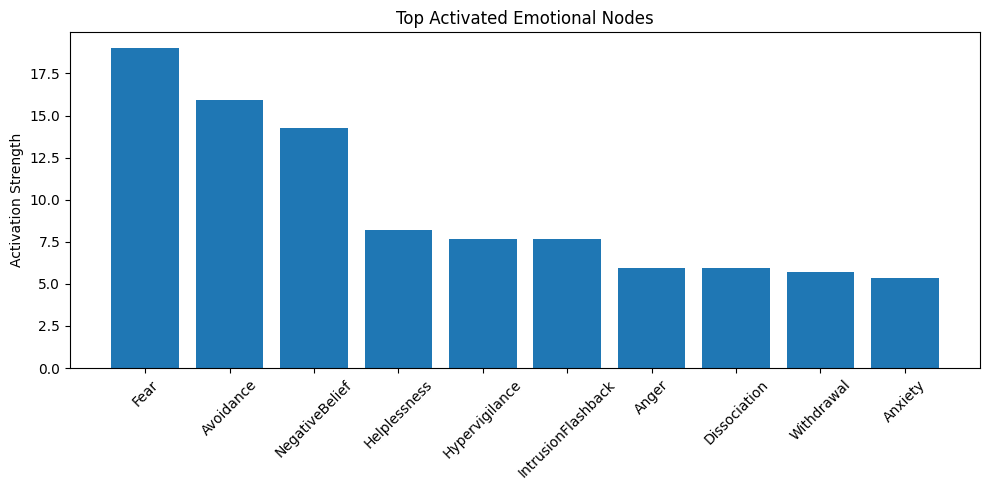

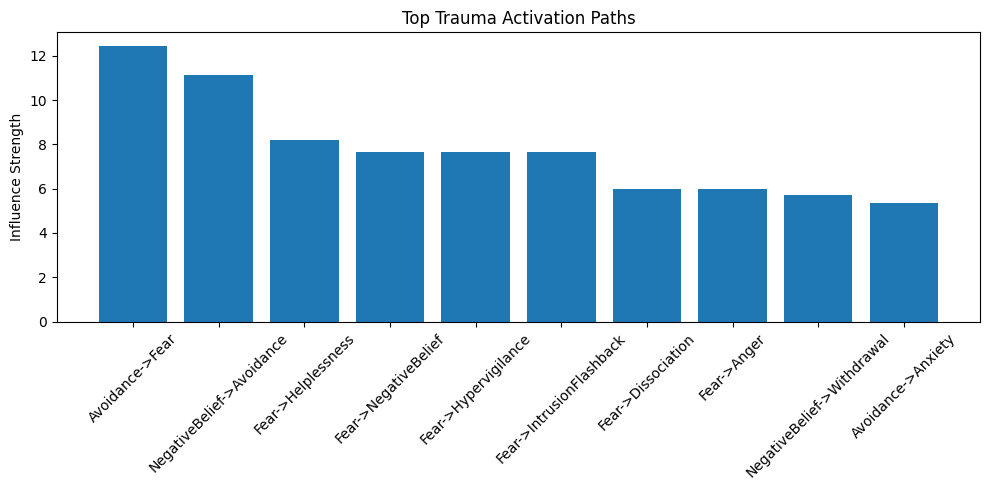


🔥 Trauma Knot 1:
Avoidance → Fear → Helplessness → NegativeBelief

💡 Weakest Break Edge:
Helplessness → NegativeBelief | weight=10.799999999999999 | break_score=21.599999999999998


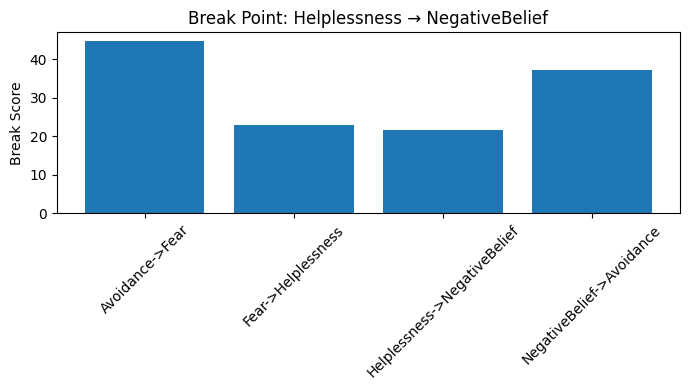


🔥 Trauma Knot 2:
Anger → NegativeBelief → Avoidance → Fear

💡 Weakest Break Edge:
Anger → NegativeBelief | weight=8.4 | break_score=8.4


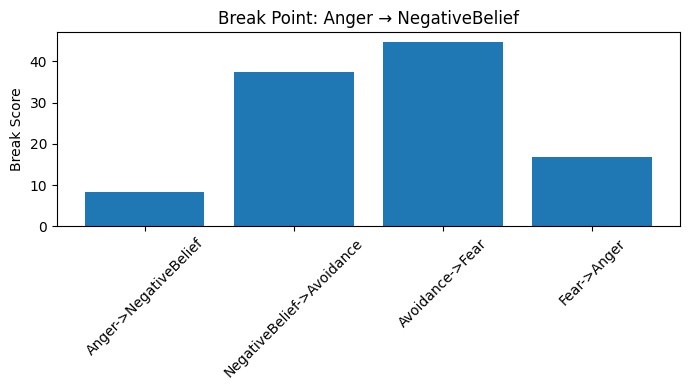


🔥 Trauma Knot 3:
Avoidance → Fear → NegativeBelief

💡 Weakest Break Edge:
Fear → NegativeBelief | weight=10.799999999999999 | break_score=21.599999999999998


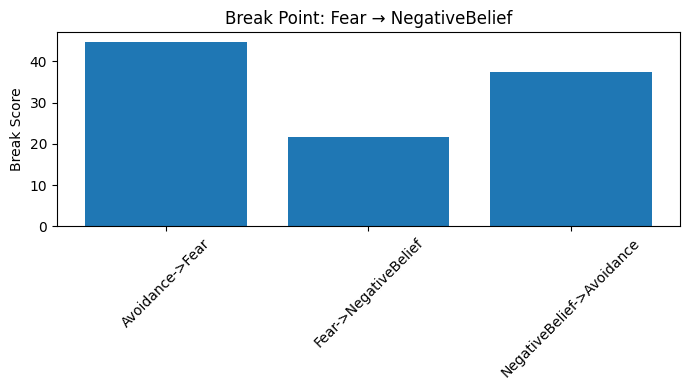


--- AFTER WEAKENING ---
[['Fear', 'Hypervigilance', 'StartleResponse'], ['Fear', 'IntrusionFlashback'], ['NegativeBelief', 'Withdrawal', 'Shame']]
48.8
K(G) after healing: 48.8


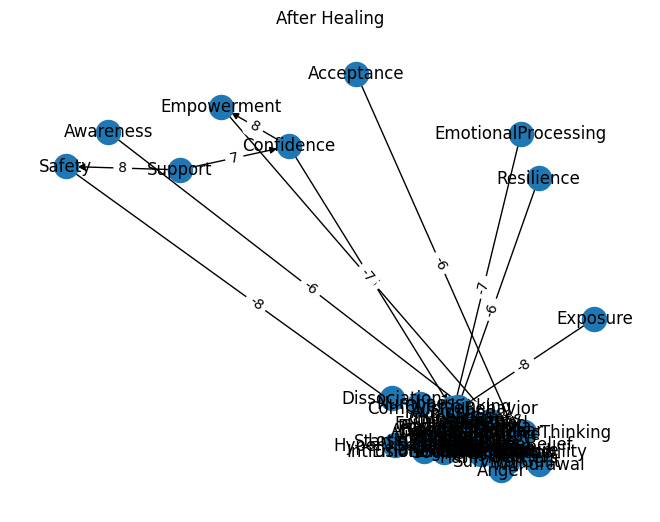


--- Activation Start: Fear ---

Step 1
Fear → NegativeBelief | influence: 0.270
Fear → Hypervigilance | influence: 0.270
Fear → IntrusionFlashback | influence: 0.270
Fear → Dissociation | influence: 0.210
Fear → Helplessness | influence: 0.144
Fear → Anger | influence: 0.210

Top activations:
Fear: 1.000
NegativeBelief: 0.270
Hypervigilance: 0.270
IntrusionFlashback: 0.270
Anger: 0.210

Step 2
NegativeBelief → Avoidance | influence: 0.016
NegativeBelief → Withdrawal | influence: 0.065
Fear → NegativeBelief | influence: 0.270
Fear → Hypervigilance | influence: 0.270
Fear → IntrusionFlashback | influence: 0.270
Fear → Dissociation | influence: 0.210
Fear → Helplessness | influence: 0.144
Fear → Anger | influence: 0.210
Anger → NegativeBelief | influence: 0.044
Helplessness → NegativeBelief | influence: 0.039
Helplessness → Avoidance | influence: 0.039
Hypervigilance → StartleResponse | influence: 0.065
IntrusionFlashback → Fear | influence: 0.081
Dissociation → Numbness | influence: 0.0

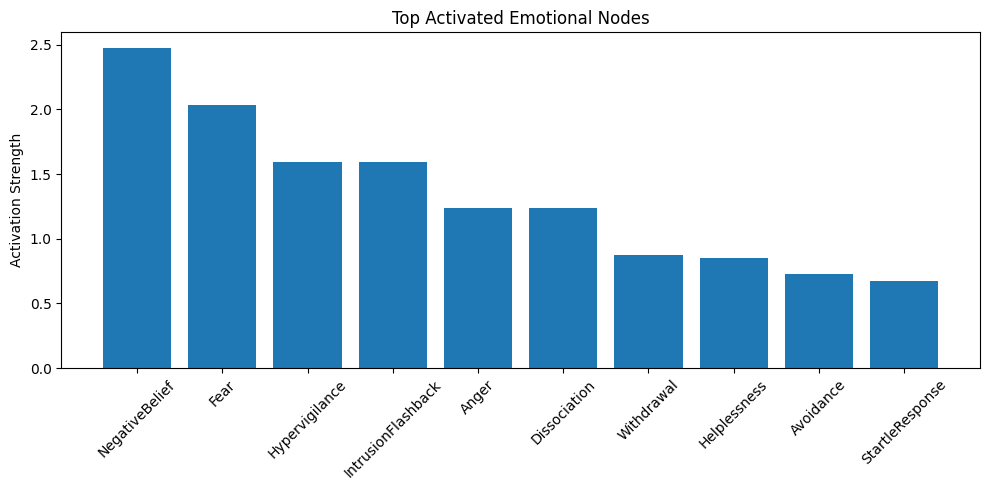

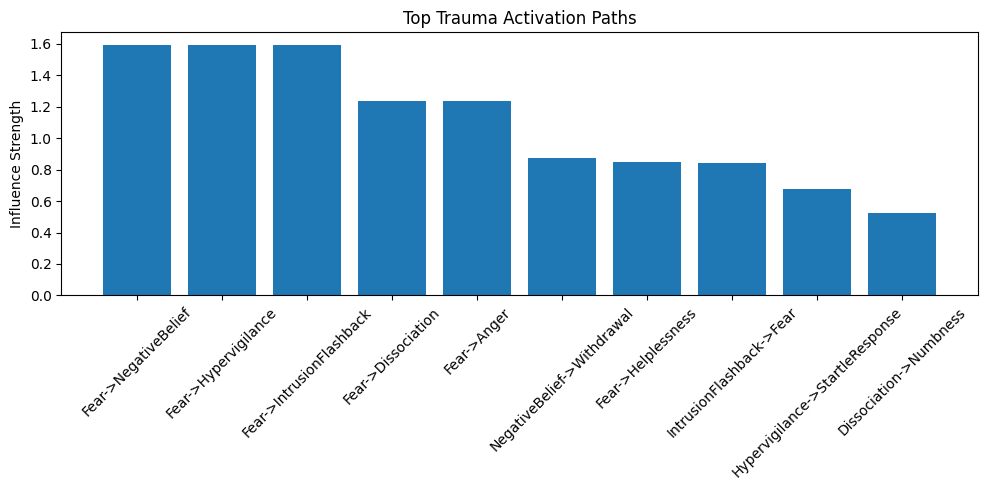


🔥 Trauma Knot 1:
Fear → Hypervigilance → StartleResponse

💡 Weakest Break Edge:
Hypervigilance → StartleResponse | weight=4.8 | break_score=4.8


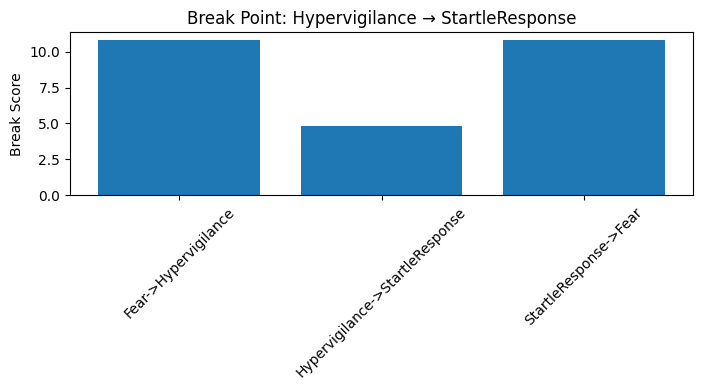


🔥 Trauma Knot 2:
Anxiety → CatastrophicThinking → NegativeBelief → Avoidance

💡 Weakest Break Edge:
NegativeBelief → Avoidance | weight=1.1663999999999999 | break_score=2.3327999999999998


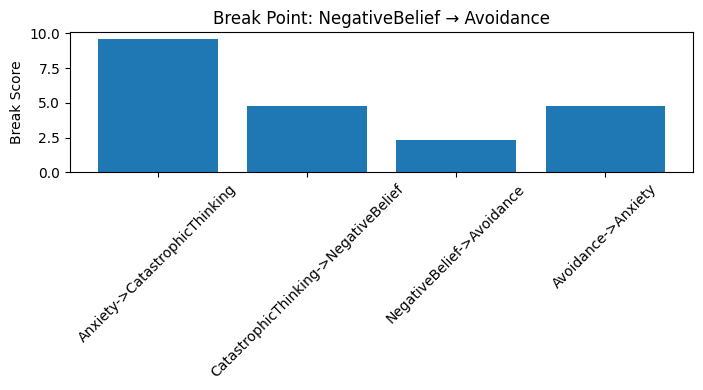


🔥 Trauma Knot 3:
Avoidance → Fear → Dissociation → Numbness

💡 Weakest Break Edge:
Avoidance → Fear | weight=0.6998399999999999 | break_score=1.3996799999999998


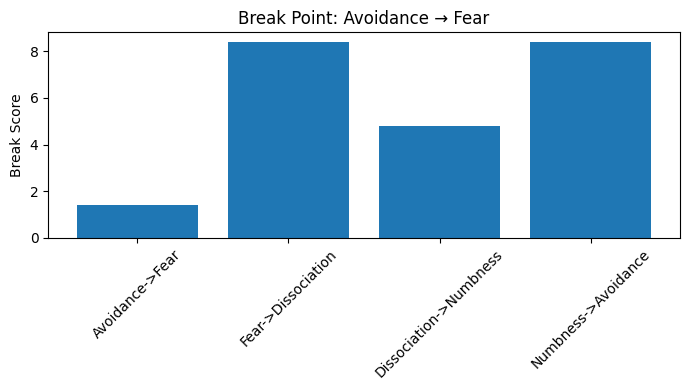

In [190]:
# ----------------------------
# 8. Run Simulation
# ----------------------------

print("\n--- INITIAL STATE ---")
cycles = get_cycles(G)
trauma_cycles = detect_trauma_cycles(G, cycles)

K_before = compute_K(G, trauma_cycles)
print("Trauma Cycles:", trauma_cycles)
print("K(G) before:", K_before)

draw_graph(G, "Before")

activation, path_tracker = simulate_activation(G, "Fear", steps=5)

plot_node_activation(activation)
plot_edge_influence(path_tracker)


knots = detect_trauma_knots(G, top_k=3)

for i, (cycle, score, edges) in enumerate(knots):

    print(f"\n🔥 Trauma Knot {i+1}:")
    print(" → ".join(cycle))

    weakest, all_edges = find_break_point_for_knot(G, cycle)

    u, v, w, bs = weakest

    print(f"\n💡 Weakest Break Edge:")
    print(f"{u} → {v} | weight={w} | break_score={bs}")

    plot_break_point(cycle, weakest, all_edges)

# ----------------------------
# Reinforce (simulate worsening trauma)
# ----------------------------
reinforce(G, trauma_cycles, factor=1.2)

print("\n--- AFTER REINFORCEMENT ---")
cycles = get_cycles(G)
trauma_cycles = detect_trauma_cycles(G, cycles)

K_reinforced = compute_K(G, trauma_cycles)
print("K(G) after reinforcement:", K_reinforced)

draw_graph(G, "After Reinforcement")


activation, path_tracker = simulate_activation(G, "Fear", steps=5)

plot_node_activation(activation)
plot_edge_influence(path_tracker)


knots = detect_trauma_knots(G, top_k=3)

for i, (cycle, score, edges) in enumerate(knots):

    print(f"\n🔥 Trauma Knot {i+1}:")
    print(" → ".join(cycle))

    weakest, all_edges = find_break_point_for_knot(G, cycle)

    u, v, w, bs = weakest

    print(f"\n💡 Weakest Break Edge:")
    print(f"{u} → {v} | weight={w} | break_score={bs}")

    plot_break_point(cycle, weakest, all_edges)

# ----------------------------
# Apply targeted healing
# ----------------------------
weaken_targeted(G, trauma_cycles, factor=0.5)

print("\n--- AFTER WEAKENING ---")
cycles = get_cycles(G)
trauma_cycles = detect_trauma_cycles(G, cycles)

K_after = compute_K(G, trauma_cycles)
print("K(G) after healing:", K_after)

draw_graph(G, "After Healing")

activation, path_tracker = simulate_activation(G, "Fear", steps=5)

plot_node_activation(activation)
plot_edge_influence(path_tracker)



knots = detect_trauma_knots(G, top_k=3)

for i, (cycle, score, edges) in enumerate(knots):

    print(f"\n🔥 Trauma Knot {i+1}:")
    print(" → ".join(cycle))

    weakest, all_edges = find_break_point_for_knot(G, cycle)

    u, v, w, bs = weakest

    print(f"\n💡 Weakest Break Edge:")
    print(f"{u} → {v} | weight={w} | break_score={bs}")

    plot_break_point(cycle, weakest, all_edges)